In [10]:
import pandas as pd
df = pd.read_csv('retail_sales.csv')
df.head()

,order_id,order_date,region,customer_segment,category,sub_category,ship_mode,quantity,unit_price,discount,sales,profit
0,ORD-1000,2023-04-13,East,Corporate,Groceries,Snacks,Standard,3,13.95,0.05,39.76,14.65
1,ORD-1001,2024-01-08,West,Corporate,Groceries,Bakery,Standard,4,13.95,0.15,47.43,13.95
2,ORD-1002,2024-01-21,North,Consumer,Groceries,Snacks,Standard,3,7.24,0.00,21.72,8.69
3,ORD-1003,2024-04-20,East,Consumer,Groceries,Bakery,Express,3,12.47,0.00,37.41,14.96
4,ORD-1004,2023-09-01,North,Corporate,Electronics,Headphones,Standard,4,204.95,0.00,819.80,327.92


In [11]:
# check for duplicate
df.duplicated().sum()

15

In [12]:
# removing duplicate
df = df.drop_duplicates()

In [13]:
# re-check for duplicate
df.duplicated().sum()

0

In [14]:
# fix inconsistent casing
df['region'].unique()

array(['East', 'West', 'North', 'South', 'west', 'south', 'north', 'east'],
      dtype=object)

In [18]:
df['region'] = df['region'].str.title()

In [19]:
# fixed inconsistent casing
df['region'].unique()

array(['East', 'West', 'North', 'South'], dtype=object)

In [20]:
# check missing values
df.isnull().sum()

order_id             0
order_date           0
region               0
customer_segment     0
category             0
sub_category         0
ship_mode           30
quantity             0
unit_price           0
discount             0
sales                0
profit               0
dtype: int64

In [22]:
# fill missing ship_mode with 'Unknown' 
df['ship_mode'] = df['ship_mode'].fillna('Unknown')

In [23]:
# re-check missing values
df.isnull().sum()

order_id            0
order_date          0
region              0
customer_segment    0
category            0
sub_category        0
ship_mode           0
quantity            0
unit_price          0
discount            0
sales               0
profit              0
dtype: int64

In [37]:
# Which region generates the most total sales?
sales_by_region = df.groupby('region')['sales'].sum().sort_values(ascending=False)
print (sales_by_region)

region
West     209102.82
South    202025.90
East     201409.96
North    177047.28
Name: sales, dtype: float64


In [39]:
sales_by_region.idxmax(), sales_by_region.max()

('West', 209102.82)

In [34]:
# Which product category is most profitable (not just highest sales)?
summary = df.groupby('category').agg(
    total_profit=('profit', 'sum'),
    total_sales=('sales', 'sum'))
summary['profit_margin'] = (summary['total_profit'] / summary['total_sales'] * 100)
summary.sort_values('total_profit', ascending=False)

,total_profit,total_sales,profit_margin
category,,,
Electronics,139065.37,384992.65,36.121565
Furniture,102368.63,279702.61,36.599097
Clothing,19751.33,54533.39,36.218783
Toys,16964.07,47118.04,36.003344
Groceries,8417.59,23239.27,36.221405


In [48]:
summary['total_profit'].idxmax(), summary['total_profit'].max()

('Electronics', 139065.37)

In [49]:
# or in short
summary = df.groupby('category')['profit'].sum()
summary.idxmax(), summary.max()

('Electronics', 139065.37)

In [56]:
# Which customer segment gives the most discounts, and does it hurt profit?
cs = df.groupby('customer_segment').agg (
    avg_profit = ('profit', 'mean'),
    avg_discount = ('discount', 'mean'))
print (cs)

                  avg_profit  avg_discount
customer_segment                          
Consumer          139.077603      0.059185
Corporate         155.870931      0.056040
Small Business    138.832598      0.058363


In [65]:
segment = cs['avg_discount'].idxmax()
segment, cs.loc[segment, 'avg_discount'], cs.loc[segment, 'avg_profit']

('Consumer', 0.0591845140032949, 139.07760296540363)

In [66]:
# Monthly sales trend — is the business growing?
df['order_date'] = pd.to_datetime(df['order_date'])
df.set_index('order_date').resample('M')['sales'].sum()

order_date
2023-01-31    41082.78
2023-02-28    21042.80
2023-03-31    34514.04
2023-04-30    28900.06
2023-05-31    44388.14
2023-06-30    31424.25
2023-07-31    34425.16
2023-08-31    32449.95
2023-09-30    32256.64
2023-10-31    42620.44
2023-11-30    28981.71
2023-12-31    26588.91
2024-01-31    31205.80
2024-02-29    33358.57
2024-03-31    35732.80
2024-04-30    26610.99
2024-05-31    31793.82
2024-06-30    41564.22
2024-07-31    33102.54
2024-08-31    34419.34
2024-09-30    31518.53
2024-10-31    32009.66
2024-11-30    23344.89
2024-12-31    36249.92
Freq: M, Name: sales, dtype: float64

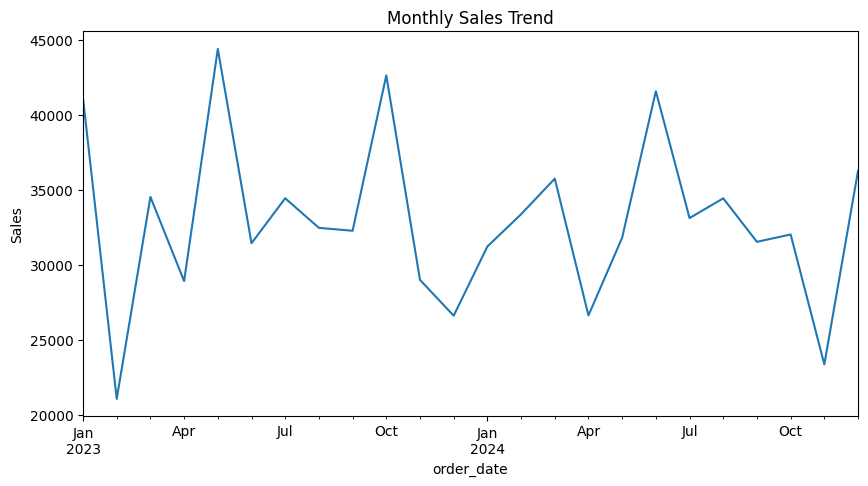

In [67]:
import matplotlib.pyplot as plt
monthly = df.set_index('order_date').resample('M')['sales'].sum()
monthly.plot(kind='line', title='Monthly Sales Trend', figsize=(10,5))
plt.ylabel('Sales')
plt.show()

In [68]:
# (Window function practice) Rank sub-categories by profit within each category
sub_profit = df.groupby(['category', 'sub_category'])['profit'].sum().reset_index()
sub_profit['rank_in_category'] = sub_profit.groupby('category')['profit'] \
    .rank(ascending=False, method='min')
sub_profit.sort_values(['category', 'rank_in_category'])

,category,sub_category,profit,rank_in_category
1,Clothing,Shirts,5192.46,1.0
2,Clothing,Shoes,5009.57,2.0
3,Clothing,Trousers,4845.01,3.0
0,Clothing,Jackets,4704.29,4.0
7,Electronics,Phones,38745.00,1.0
6,Electronics,Laptops,36083.47,2.0
4,Electronics,Cameras,33437.45,3.0
5,Electronics,Headphones,30799.45,4.0
11,Furniture,Tables,28425.34,1.0
10,Furniture,Sofas,26397.86,2.0
